<a href="https://colab.research.google.com/github/dokunoale/chagas/blob/CNN-model/CNN-dataset2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone --branch CNN-model --single-branch https://github.com/dokunoale/chagas.git
%cd chagas
# Carica librerie installate
!pip install wfdb -q
!pip install gdown -q

# Aggiungi solo la root del progetto (src)
import sys
sys.path.append('/content/chagas/src')

# Importa tutto dai moduli
from preprocessing import tf_dataset_loader
from models import libraries, functions, split_dataset
from models.CNN import build_model

# Importa simboli specifici (se vuoi)
from models.libraries import *
from models.functions import *
from models.split_dataset import *
from models.CNN.build_model import *

Cloning into 'chagas'...
remote: Enumerating objects: 180, done.
remote: Counting objects: 100% (135/135), done.
remote: Compressing objects: 100% (91/91), done.
remote: Total 180 (delta 73), reused 81 (delta 41), pack-reused 45 (from 1)
Receiving objects: 100% (180/180), 635.01 KiB | 11.76 MiB/s, done.
Resolving deltas: 100% (78/78), done.
/content/chagas
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 89.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.0 which is incompatible.
dask-cudf-cu12 25.2.2 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.0 which is incompatible.
cudf-cu12 25.2.1 requires pand

In [3]:
from google.colab import drive
drive.mount('/content/drive')

url = "https://drive.google.com/file/d/1LHx76N0LCDlGyJTLkVegVDolXcSgkppa/view?usp=drive_link"
gdown.download(url, "dataset.zip", quiet=False, fuzzy=True)
!unzip -q dataset.zip -d ./dataset

Mounted at /content/drive


Downloading...
From (original): https://drive.google.com/uc?id=1LHx76N0LCDlGyJTLkVegVDolXcSgkppa
From (redirected): https://drive.google.com/uc?id=1LHx76N0LCDlGyJTLkVegVDolXcSgkppa&confirm=t&uuid=2f700588-9105-435f-9e90-f0a8988c7ae8
To: /content/chagas/dataset.zip
100%|██████████| 556M/556M [00:11<00:00, 46.9MB/s]


In [5]:
X_pos, y_pos = tf_dataset_loader.load_dataset('/content/chagas/dataset/preprocessed_new_conf/positives')
X_neg, y_neg = tf_dataset_loader.load_dataset('/content/chagas/dataset/preprocessed_new_conf/negatives')
#Uniamo i positivi e i negativi
X = np.concatenate([X_pos, X_neg], axis=0)
y = np.concatenate([y_pos, y_neg], axis=0)

# Facciamo lo shuffle
indices = np.arange(X.shape[0])
np.random.shuffle(indices)

# Riordinamento di X e y con gli stessi indici
X = X[indices]
y = y[indices]

In [7]:
print(X.shape)

(9393, 2800, 12)


In [8]:
#SPLIT DEL DATASET
X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(X, y)

# MODELLO
Proviamo col nuovo dataset ad addestrare il secondo modello (solo CNN blocks + focal loss)

In [9]:
model2 = build_cnn_ecg_model()

#compiliamo il modello
model2.compile(optimizer='adam',
              loss=focal_loss(),
              metrics=['accuracy', AUC(name='auc')])

#addestriamo il modello
callback = make_callback("2_CNN")

cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: cw[0], 1: cw[1]}

history2 = model2.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=30,
                    batch_size=32,
                    class_weight=class_weights,
                    callbacks=callback)

Epoch 1/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.6940 - auc: 0.6480 - loss: 0.0518
Epoch 1: val_auc improved from -inf to 0.68723, saving model to 2_CNN_best_model.h5


177/177 ━━━━━━━━━━━━━━━━━━━━ 125s 668ms/step - accuracy: 0.6941 - auc: 0.6481 - loss: 0.0518 - val_accuracy: 0.7094 - val_auc: 0.6872 - val_loss: 0.0446 - learning_rate: 0.0010
Epoch 2/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - accuracy: 0.7151 - auc: 0.7067 - loss: 0.0433
Epoch 2: val_auc improved from 0.68723 to 0.72057, saving model to 2_CNN_best_model.h5


177/177 ━━━━━━━━━━━━━━━━━━━━ 140s 662ms/step - accuracy: 0.7151 - auc: 0.7067 - loss: 0.0433 - val_accuracy: 0.7270 - val_auc: 0.7206 - val_loss: 0.0405 - learning_rate: 0.0010
Epoch 3/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.7256 - auc: 0.7170 - loss: 0.0391
Epoch 3: val_auc improved from 0.72057 to 0.72258, saving model to 2_CNN_best_model.h5


177/177 ━━━━━━━━━━━━━━━━━━━━ 141s 659ms/step - accuracy: 0.7256 - auc: 0.7170 - loss: 0.0391 - val_accuracy: 0.7211 - val_auc: 0.7226 - val_loss: 0.0397 - learning_rate: 0.0010
Epoch 4/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.7149 - auc: 0.7321 - loss: 0.0413
Epoch 4: val_auc improved from 0.72258 to 0.73627, saving model to 2_CNN_best_model.h5


177/177 ━━━━━━━━━━━━━━━━━━━━ 140s 649ms/step - accuracy: 0.7150 - auc: 0.7321 - loss: 0.0413 - val_accuracy: 0.7121 - val_auc: 0.7363 - val_loss: 0.0395 - learning_rate: 0.0010
Epoch 5/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.7055 - auc: 0.7320 - loss: 0.0421
Epoch 5: val_auc improved from 0.73627 to 0.73854, saving model to 2_CNN_best_model.h5


...

177/177 ━━━━━━━━━━━━━━━━━━━━ 141s 651ms/step - accuracy: 0.7681 - auc: 0.8342 - loss: 0.0295 - val_accuracy: 0.7632 - val_auc: 0.8505 - val_loss: 0.0276 - learning_rate: 0.0010
Epoch 22/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.7970 - auc: 0.8731 - loss: 0.0224
Epoch 22: val_auc improved from 0.85046 to 0.85254, saving model to 2_CNN_best_model.h5


177/177 ━━━━━━━━━━━━━━━━━━━━ 142s 653ms/step - accuracy: 0.7970 - auc: 0.8731 - loss: 0.0224 - val_accuracy: 0.7680 - val_auc: 0.8525 - val_loss: 0.0280 - learning_rate: 0.0010
Epoch 23/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.8016 - auc: 0.8825 - loss: 0.0215
Epoch 23: val_auc improved from 0.85254 to 0.88387, saving model to 2_CNN_best_model.h5


177/177 ━━━━━━━━━━━━━━━━━━━━ 142s 651ms/step - accuracy: 0.8016 - auc: 0.8825 - loss: 0.0215 - val_accuracy: 0.8031 - val_auc: 0.8839 - val_loss: 0.0265 - learning_rate: 0.0010
Epoch 24/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.8069 - auc: 0.8808 - loss: 0.0208
Epoch 24: val_auc did not improve from 0.88387
177/177 ━━━━━━━━━━━━━━━━━━━━ 142s 650ms/step - accuracy: 0.8069 - auc: 0.8808 - loss: 0.0208 - val_accuracy: 0.7951 - val_auc: 0.8699 - val_loss: 0.0307 - learning_rate: 0.0010
Epoch 25/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 595ms/step - accuracy: 0.7870 - auc: 0.8510 - loss: 0.0282
Epoch 25: val_auc did not improve from 0.88387
177/177 ━━━━━━━━━━━━━━━━━━━━ 116s 654ms/step - accuracy: 0.7870 - auc: 0.8511 - loss: 0.0281 - val_accuracy: 0.7717 - val_auc: 0.8819 - val_loss: 0.0238 - learning_rate: 0.0010
Epoch 26/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 595ms/step - accuracy: 0.8096 - auc: 0.8857 - loss: 0.0196
Epoch 26: val_auc did not improve from 0.88387
177/177 ━━━━━━━━━━━

177/177 ━━━━━━━━━━━━━━━━━━━━ 144s 652ms/step - accuracy: 0.8228 - auc: 0.8988 - loss: 0.0185 - val_accuracy: 0.7999 - val_auc: 0.8862 - val_loss: 0.0239 - learning_rate: 5.0000e-04
Epoch 29/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.8353 - auc: 0.9069 - loss: 0.0172
Epoch 29: val_auc improved from 0.88617 to 0.89173, saving model to 2_CNN_best_model.h5


177/177 ━━━━━━━━━━━━━━━━━━━━ 141s 649ms/step - accuracy: 0.8353 - auc: 0.9069 - loss: 0.0172 - val_accuracy: 0.8121 - val_auc: 0.8917 - val_loss: 0.0246 - learning_rate: 5.0000e-04
Epoch 30/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.8165 - auc: 0.9081 - loss: 0.0174
Epoch 30: val_auc did not improve from 0.89173
177/177 ━━━━━━━━━━━━━━━━━━━━ 140s 639ms/step - accuracy: 0.8165 - auc: 0.9081 - loss: 0.0174 - val_accuracy: 0.7898 - val_auc: 0.8915 - val_loss: 0.0229 - learning_rate: 5.0000e-04


In [10]:
#Facciamo le predizioni
y_pred_proba = model2.predict(X_test).flatten()

#Troviamo la soglia ottimale
optimal_threshold = find_optimal_threshold(y_test, y_pred_proba)
print(f"Soglia ottimale: {optimal_threshold}")

# Applica soglia ottimale per binarizzare le predizioni
y_pred_binary = (y_pred_proba >= optimal_threshold).astype(int)

59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step
Soglia ottimale: 0.244
Soglia ottimale: 0.24360287189483643


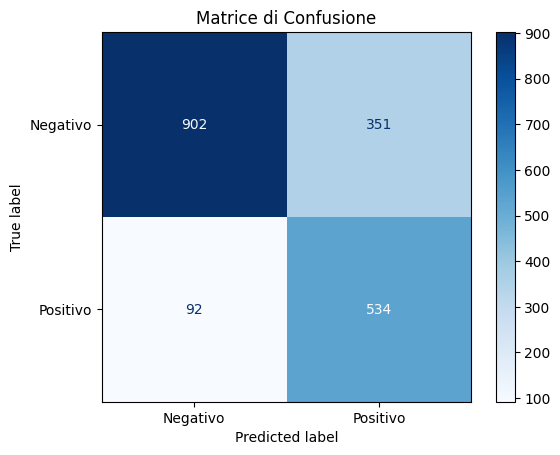

In [11]:
#Calcoliamo la matrice di confusione e la visualizziamo
cm2 = confusion_matrix(y_test, y_pred_binary)
show_confusion_matrix(cm2)